<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/Hands_On_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [183]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1033)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 16.5 #0.5*33
beta0 = 43     #10+33
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


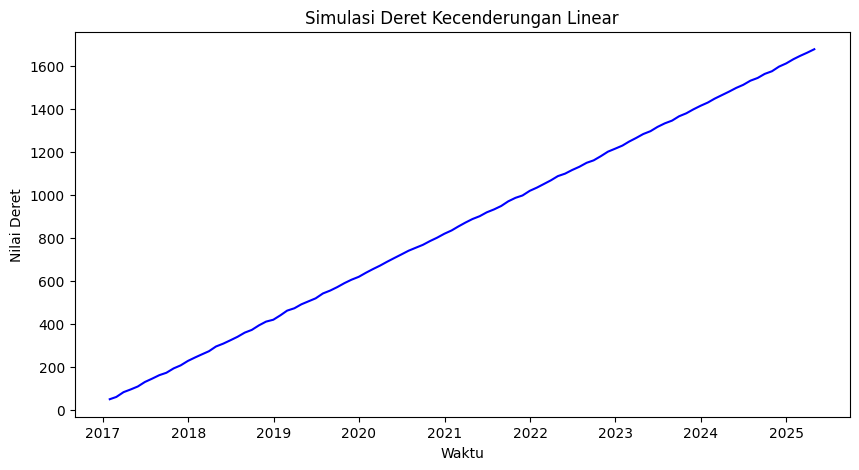

In [184]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Ketika nilai koefisien tren β₁ diubah dari 0,5 menjadi 33,5, terjadi peningkatan kemiringan tren yang sangat besar, sedangkan standar deviasi white noise tetap sebesar 2.

Perbandingan antara standar deviasi white noise dan kenaikan tren setiap periode adalah

$$ \frac{\sigma_\varepsilon}{\beta_1} =\frac{2}{33,5} \approx 0,060. $$

Artinya, standar deviasi white noise hanya sekitar 6% dari besarnya kenaikan tren pada setiap periode. Kondisi tersebut menyebabkan variasi acak relatif kecil dibandingkan dengan perubahan tren, sehingga fluktuasi akibat white noise menjadi kurang terlihat secara visual dan deret waktu tampak hampir membentuk garis lurus dengan kecenderungan meningkat yang sangat kuat.

In [185]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [186]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.091e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.94e-233
Time:                        13:01:57   Log-Likelihood:                -215.55
No. Observations:                 100   AIC:                             435.1
Df Residuals:                      98   BIC:                             440.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           43.3100      0.419    103.406   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Apakah model regresi yang dipaskan sudah bagus?

Hasil pengepasan model regresi linear menunjukkan bahwa estimasi parameter sangat mendekati parameter sebenarnya yang digunakan dalam pembangkitan data. Parameter intersep yang sebenarnya sebesar 43 menghasilkan estimasi sebesar 43,3100, sedangkan parameter kemiringan sebesar 16,5 menghasilkan estimasi sebesar 16,4922. Nilai \(R^2\) sebesar 1,000 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Selain itu, nilai Durbin-Watson sebesar 2,085 menunjukkan tidak terdapat indikasi autokorelasi residual yang berarti. Dengan demikian, model regresi linear yang dipaskan dapat dikatakan sangat baik dalam merepresentasikan pola linear data yang dibangkitkan.

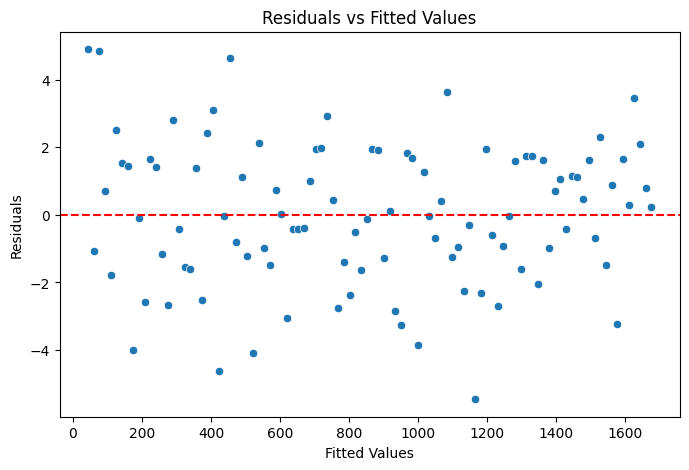

In [187]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

Berdasarkan plot Residuals vs Fitted Values, residual tersebar secara acak di sekitar garis nol dan tidak menunjukkan pola sistematis maupun pola melengkung. Selain itu, penyebaran residual relatif konstan pada berbagai nilai fitted values sehingga tidak terlihat indikasi heteroskedastisitas. Plot ini merupakan **diagnosis visual**, sehingga keputusan akhir mengenai asumsi perlu didukung oleh uji statistik.

In [188]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.0391


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

Hipotesis nol Breusch-Pagan adalah **varian residual konstan (homoskedastisitas)**. Jika $p$-value $>0.05$, $H_0$ gagal ditolak sehingga tidak terdapat bukti yang cukup untuk menyatakan adanya heteroskedastisitas. Jika $p$-value $\leq0.05$, terdapat indikasi heteroskedastisitas.

Besarnya slope $beta_1$ tidak dengan sendirinya menyebabkan heteroskedastisitas. Heteroskedastisitas berkaitan dengan perubahan ragam residual terhadap level/prediktor.


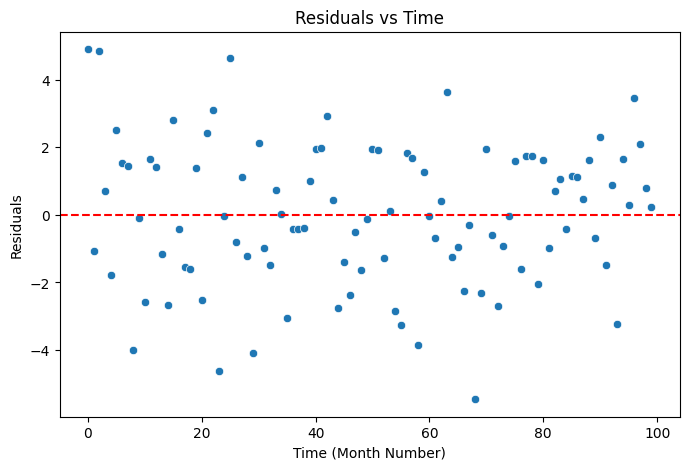

In [189]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

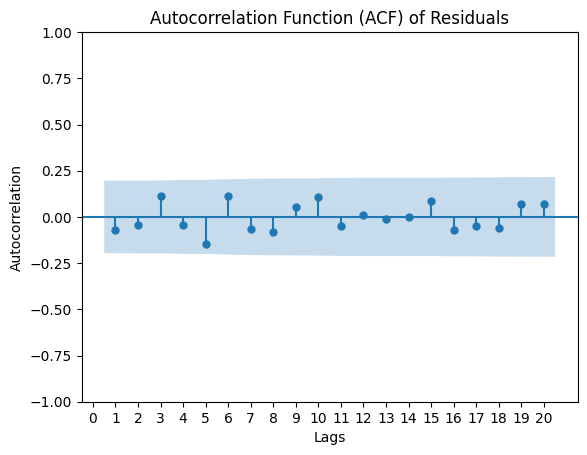

In [190]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Plot Residuals vs Time Titik residual tersebar di sekitar garis nol dan tidak adanya indikasi kuat pola sistematis pada residual. Hal ini mendukung asumsi bahwa model linear sudah cukup sesuai dan secara visual residual memiliki varians yang relatif konstan.

Plot ACF Residual Batang ACF pada lag 1–20 seluruhnya berada di dalam batas interval kepercayaan (area biru). Artinya tidak ada lag yang menunjukkan autokorelasi yang signifikan secara visual.

Keduanya merupakan diagnosis viusual sehingga perlu dilanjutkan dengan **uji formal**; seperti Ljung--Box

In [191]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)

# Menampilkan lag yang signifikan
significant_lag = ljung_box_test[
    ljung_box_test['lb_pvalue'] < 0.05
]

if len(significant_lag) == 0:
    print("\nKesimpulan: Tidak terdapat autokorelasi residual.")
else:
    print("\nKesimpulan: Terdapat indikasi autokorelasi pada:")
    print(significant_lag)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.506068   0.476846
2    0.722209   0.696906
3    2.019500   0.568369
4    2.216753   0.695963
5    4.526634   0.476328
6    5.887750   0.435881
7    6.375381   0.496664
8    7.109687   0.524846
9    7.419169   0.593564
10   8.801569   0.551033
11   9.062115   0.616159
12   9.074790   0.696529
13   9.087322   0.766317
14   9.087352   0.825414
15   9.962655   0.822082
16  10.537303   0.837105
17  10.851163   0.864196
18  11.293204   0.881503
19  11.951635   0.887682

Kesimpulan: Tidak terdapat autokorelasi residual.


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Ljung--Box menguji $H_0$: tidak terdapat autokorelasi residual secara bersama-sama sampai lag tertentu. Interpretasi dilakukan dari **p-value pada setiap lag**. Jika p-value $>0.05$, tidak ada bukti yang cukup untuk menolak $H_0$ pada lag tersebut. Sehingga dapat disimpulkan bahwa **Tidak terdapat autokorelasi residual**

Untuk residual yang benar-benar menyerupai white noise, diharapkan tidak ada pola autokorelasi yang sistematis pada berbagai lag.

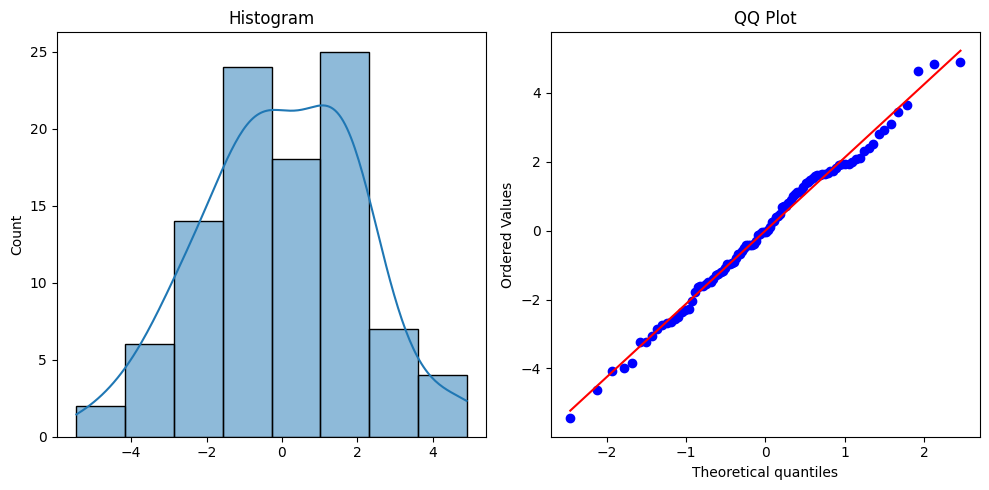

In [192]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Histogram yang relatif simetris dan Q-Q plot yang titik-titiknya mengikuti garis referensi mendukung asumsi normalitas secara visual. Penyimpangan pada bagian ekor masih dapat terjadi karena ukuran sampel dan variasi acak.

In [193]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")
if shapiro_p_value > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")


Shapiro-Wilk Test: Statistics = 0.9913861600242676, p-value = 0.7751889016538775
Kesimpulan: Residual berdistribusi normal.


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Hasil uji Shapiro Wilk menunjukan p-value diatas 0,05 atau tidak signifikan untuk menolak hipotesis Nol. Hasil ini konsisten dengan histogram dan Q-Q plot, yang menunjukkan bahwa residual secara umum mengikuti pola distribusi normal. Oleh karena itu, asumsi normalitas residual dapat dianggap terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [194]:
# Menentukan parameter simulasi
np.random.seed(1033)
n_periods = 120
beta_0, beta_1, beta_2= 88, 16.5, 0.66 #50+33, 0.5*33, 0.02*33
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

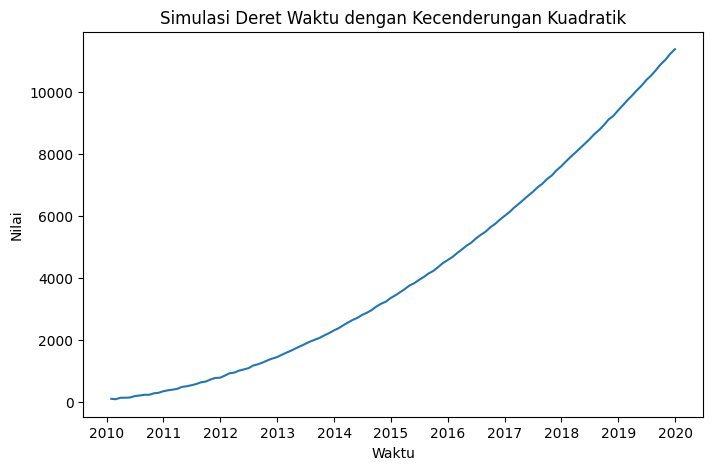

In [195]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Berdasarkan plot, deret menunjukkan pola kecenderungan meningkat yang bersifat kuadratik. Nilai deret meningkat dari waktu ke waktu dan laju peningkatannya semakin besar. Hal ini terlihat dari bentuk kurva yang semakin curam pada periode-periode akhir. Selain kecenderungan meningkat tersebut, terdapat fluktuasi acak di sekitar kecenderungan utama yang berasal dari komponen noise ε
t. Namun, karena skala komponen kuadratik sangat besar dibandingkan dengan standar deviasi noise sebesar 10 sehingga grafik hampir mulus secara visual.

Berbeda dengan trend linear yang memiliki kemiringan relatif konstan, trend kuadratik menunjukkan bahwa perubahan nilai dari satu periode ke periode berikutnya semakin besar.

In [196]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.190e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.16e-294
Time:                        13:01:59   Log-Likelihood:                -450.71
No. Observations:                 120   AIC:                             907.4
Df Residuals:                     117   BIC:                             915.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         92.4652      2.823     32.751      0.0

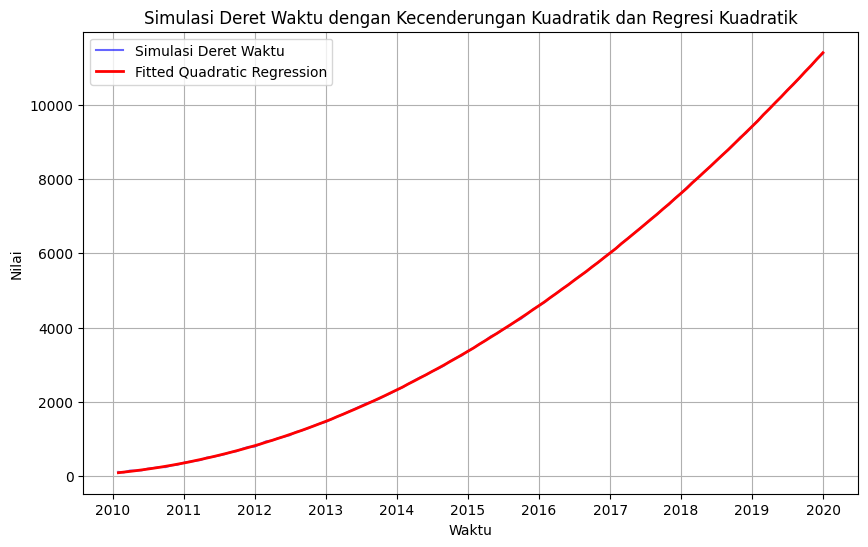

In [197]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Model regresi kuadratik yang dipaskan sudah tepat dalam merepresentasikan deret yang dibangkitkan. Hal ini ditunjukkan oleh estimasi parameter yang mendekati parameter sebenarnya, yaitu $\hat\beta_0=92,4652$, $\hat\beta_1=16,313$, dan $\hat\beta_2=0,6612$, dibandingkan dengan parameter simulasi $\hat\beta_0=88$, $\hat\beta_1=16,5$, dan $\hat\beta_2=0,66$. Koefisien kuadratik sangat signifikan dengan \(p<0,001\), sehingga keberadaan kecenderungan kuadratik didukung secara statistik. Nilai $R^2$ yang sangat mendekati 1 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi deret. Selain itu, nilai Durbin-Watson sebesar 2,244 tidak menunjukkan adanya autokorelasi residual yang kuat, sedangkan hasil uji Omnibus dan Jarque-Bera tidak menunjukkan penyimpangan normalitas residual yang signifikan. Dengan demikian, model regresi kuadratik dapat digunakan untuk merepresentasikan pola kecenderungan deret tersebut.

In [198]:
# cek asumsi model regresi kuadratik

In [199]:
# cek asumsi model regresi kuadratik
# 1. UJI HETEROSKEDASTISITAS
#    Breusch-Pagan Test

bp_test = het_breuschpagan(
    model_quad.resid,
    model_quad.model.exog
)

print("\n================================================")
print("UJI BREUSCH-PAGAN")
print("================================================")

print(f"LM Statistic : {bp_test[0]:.4f}")
print(f"LM P-value   : {bp_test[1]:.4f}")
print(f"F Statistic  : {bp_test[2]:.4f}")
print(f"F P-value    : {bp_test[3]:.4f}")

if bp_test[1] > 0.05:
    print("Kesimpulan: Tidak terdapat heteroskedastisitas.")
else:
    print("Kesimpulan: Terdapat indikasi heteroskedastisitas.")



UJI BREUSCH-PAGAN
LM Statistic : 4.5079
LM P-value   : 0.1050
F Statistic  : 2.2834
F P-value    : 0.1065
Kesimpulan: Tidak terdapat heteroskedastisitas.


In [200]:
# 2. UJI AUTOKORELASI
#    Ljung-Box Test

ljung_box_test = acorr_ljungbox(
    model_quad.resid,
    lags=range(1, 20),
    return_df=True
)

print("\n================================================")
print("UJI LJUNG-BOX")
print("================================================")

print(ljung_box_test)

# Menampilkan lag yang signifikan
significant_lag = ljung_box_test[
    ljung_box_test['lb_pvalue'] < 0.05
]

if len(significant_lag) == 0:
    print("\nKesimpulan: Tidak terdapat autokorelasi residual.")
else:
    print("\nKesimpulan: Terdapat indikasi autokorelasi pada:")
    print(significant_lag)




UJI LJUNG-BOX
      lb_stat  lb_pvalue
1    2.875041   0.089963
2    3.195415   0.202360
3    5.095404   0.164943
4    5.960928   0.202085
5    8.036859   0.154216
6    8.789961   0.185740
7   10.076199   0.184296
8   10.303321   0.244379
9   10.322033   0.325049
10  10.529444   0.395333
11  10.546183   0.482027
12  10.905752   0.537013
13  11.371065   0.579763
14  11.492092   0.647019
15  12.459262   0.643986
16  13.378689   0.644894
17  13.642612   0.692219
18  14.925848   0.667052
19  15.735534   0.674844

Kesimpulan: Tidak terdapat autokorelasi residual.


In [201]:
# 3. UJI NORMALITAS RESIDUAL
#    Shapiro-Wilk Test

shapiro_stat, shapiro_p_value = stats.shapiro(model_quad.resid)

print("\n================================================")
print("UJI SHAPIRO-WILK")
print("================================================")

print(f"Statistic : {shapiro_stat:.4f}")
print(f"P-value   : {shapiro_p_value:.4f}")

if shapiro_p_value > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")


UJI SHAPIRO-WILK
Statistic : 0.9894
P-value   : 0.4829
Kesimpulan: Residual berdistribusi normal.


In [202]:
# 9. RINGKASAN HASIL UJI ASUMSI
print("\n================================================")
print("RINGKASAN UJI ASUMSI")
print("================================================")

print(f"Breusch-Pagan p-value : {bp_test[1]:.4f}")
print(f"Ljung-Box minimum p-value : {ljung_box_test['lb_pvalue'].min():.4f}")
print(f"Shapiro-Wilk p-value  : {shapiro_p_value:.4f}")


RINGKASAN UJI ASUMSI
Breusch-Pagan p-value : 0.1050
Ljung-Box minimum p-value : 0.0900
Shapiro-Wilk p-value  : 0.4829


Ujia asumsi model regresi kuadratik memenuhi asumsi Tidak terdapat heteroskedastisitas, Tidak Ada Autokorelasi Residual, dan Berdistribusi Normal

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [203]:
# Menentukan parameter simulasi
np.random.seed(1033)
n_periods = 120
beta0, beta1, beta2=88, -825, -66
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


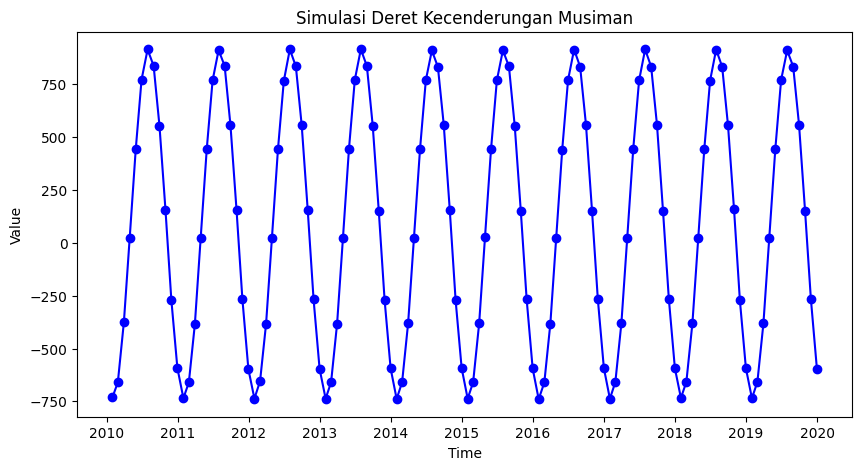

In [204]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Deret tersebut menunjukkan pola musiman dengan periode 12 bulan. Hal ini ditunjukkan oleh komponen sinusoidal dengan frekuensi \(f=1/12\), sehingga pola deret berulang setiap 12 periode. Deret tidak memiliki komponen tren sehingga tidak menunjukkan kecenderungan meningkat atau menurun secara sistematis dalam jangka panjang. Nilai deret berfluktuasi mengikuti pola naik-turun yang relatif sama pada setiap tahun di sekitar level dasar sebesar 88. Variasi kecil di sekitar pola musiman disebabkan oleh adanya noise acak dengan rata-rata nol dan simpangan baku 2. Dengan demikian, karakteristik utama deret adalah adanya pola musiman tahunan yang kuat tanpa kecenderungan tren.

karena $\beta_1=-825$ dan $\beta_2=-66$, amplitudo musimannya sangat besar. Amplitudo gabungan secara matematis adalah

$$ A=\sqrt{(-825)^2+(-66)^2}\approx827{,}64. $$

Jadi nilai deret akan berfluktuasi kira-kira pada rentang

$$ 88-827{,}64\quad\text{sampai}\quad88+827{,}64, $$

atau sekitar −740 sampai 916, sebelum memperhitungkan noise

In [205]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [206]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [207]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [208]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.641e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.47e-261
Time:                        13:01:59   Log-Likelihood:                -251.75
No. Observations:                 120   AIC:                             527.5
Df Residuals:                     108   BIC:                             560.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -736.4444      0.657  -1120.441      0.0

Bagaimana interpretasi dari hasil tersebut?

Karena model **tidak memiliki intercept** dan memiliki 12 dummy bulan, setiap koefisien langsung merupakan estimasi **rataan untuk bulan tersebut**. Misalnya koefisien Januari adalah estimasi rataan Januari, koefisien Februari adalah estimasi rataan Februari, dan seterusnya.

Model ini berbeda dari model harmonik: dummy tidak memaksakan bentuk sinusoidal, sehingga setiap bulan dapat mempunyai rataan sendiri.

In [209]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

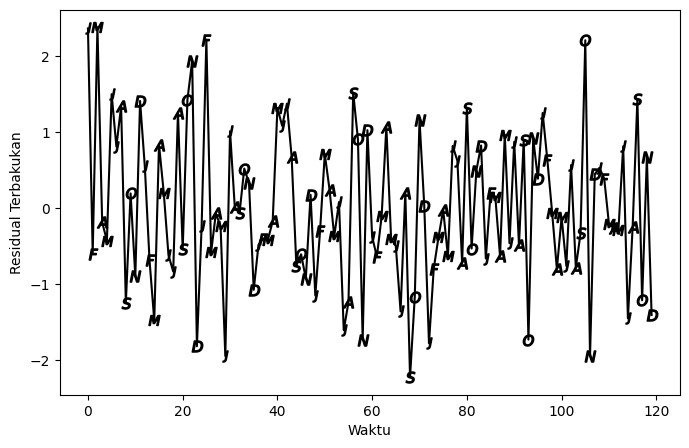

In [210]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


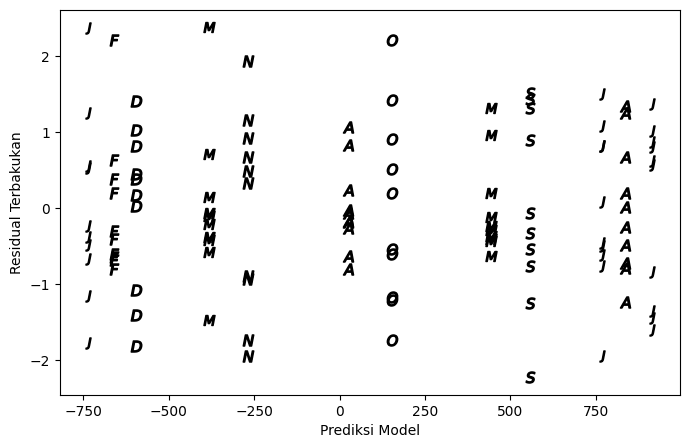

In [211]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

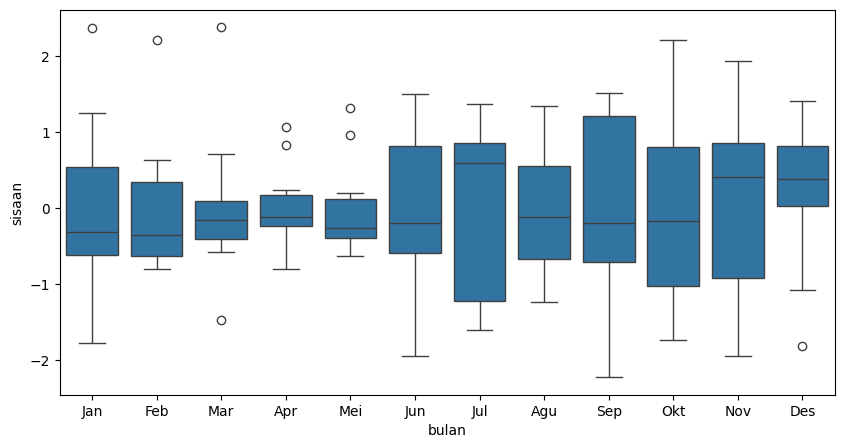

In [212]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

1. **Residual vs waktu**: digunakan untuk melihat pola sistematis atau perubahan ragam sepanjang waktu.
2. **Residual vs fitted**: digunakan untuk melihat ketidaklinieran dan perubahan ragam residual.
3. **Boxplot residual menurut bulan**: membantu melihat apakah residual cenderung berbeda atau memiliki penyebaran berbeda antarbulan.

Tidak adanya pola yang jelas mendukung kecukupan model, tetapi uji formal tetap diperlukan.

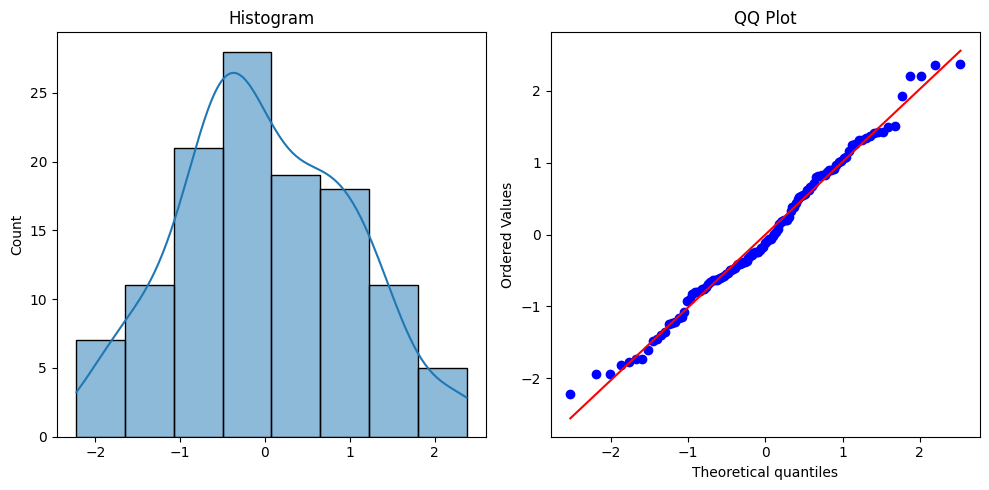

In [213]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

Jika pada plot data aktual dan nilai fitted terlihat hampir berhimpit, hal tersebut menunjukkan bahwa model berhasil menangkap pola musiman yang terdapat dalam data.

Pola yang dihasilkan menunjukan siklus yang berulang setiap 12 bulan dimana karakteristik dari masing-masing bulan yaitu
Januari: nilai sangat rendah; Februari–April: mulai meningkat; Mei–Juli: meningkat hingga mencapai puncak; Juli: mencapai nilai tertinggi; Agustus–Desember: kembali menurun; dan Desember: kembali berada pada nilai rendah.
Disamping itu nilai $$ R^2=1.000 $$, menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data.



In [214]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [215]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [216]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.641e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.47e-261
Time:                        13:02:02   Log-Likelihood:                -251.75
No. Observations:                 120   AIC:                             527.5
Df Residuals:                     108   BIC:                             560.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -736.4444      0.657  -1120.441      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

In [217]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [218]:
# Parameter
np.random.seed(1033)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*33, 10*33 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


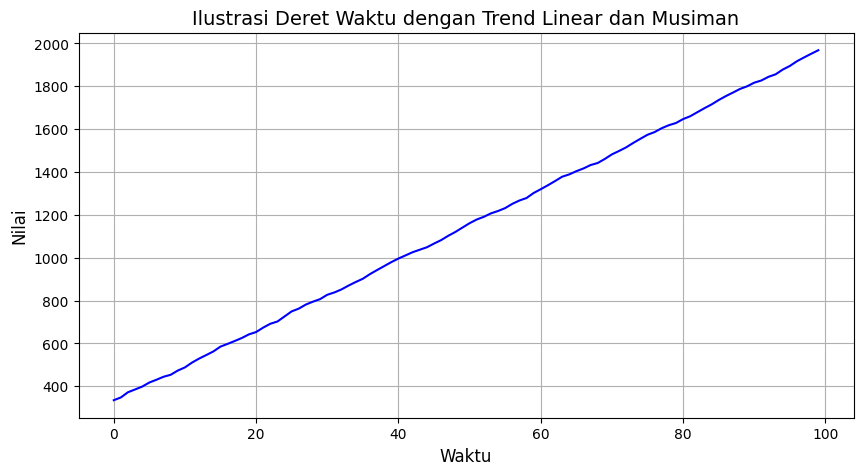

In [219]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [220]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [221]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [222]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.313e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.72e-202
Time:                        13:02:02   Log-Likelihood:                -208.76
No. Observations:                 100   AIC:                             443.5
Df Residuals:                      87   BIC:                             477.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      330.8120      0.780    424.250      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

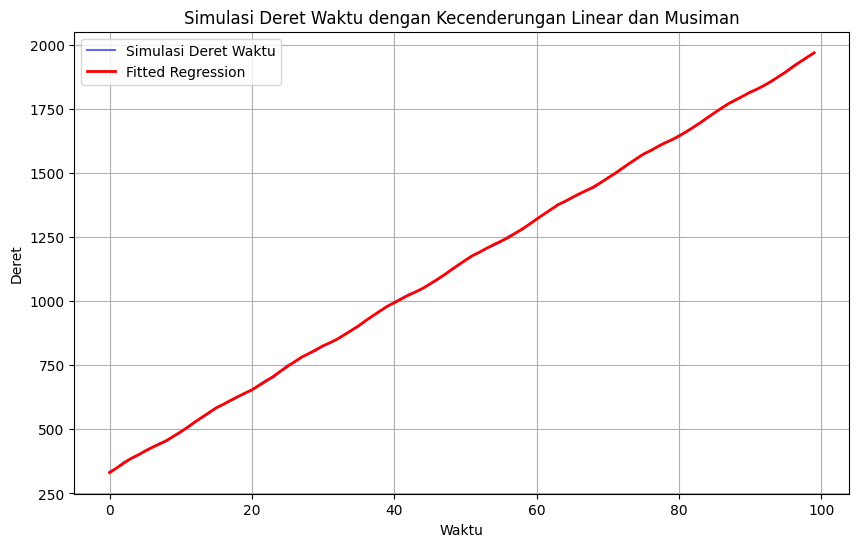

In [223]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [224]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [225]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

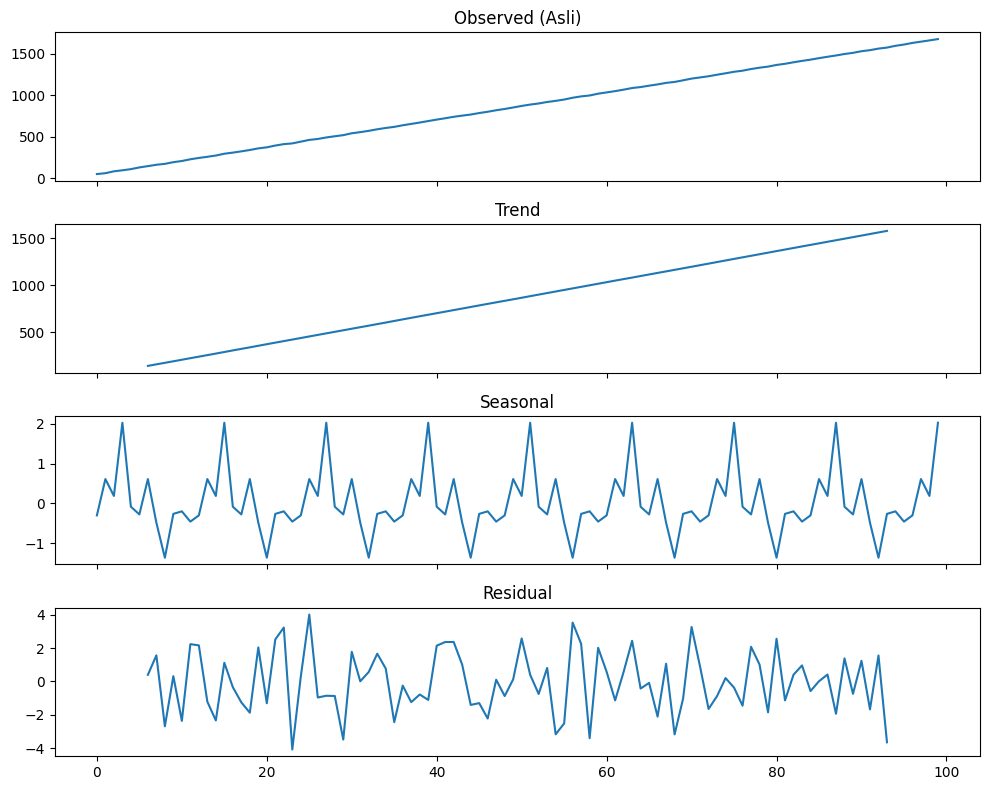

In [226]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

In [227]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

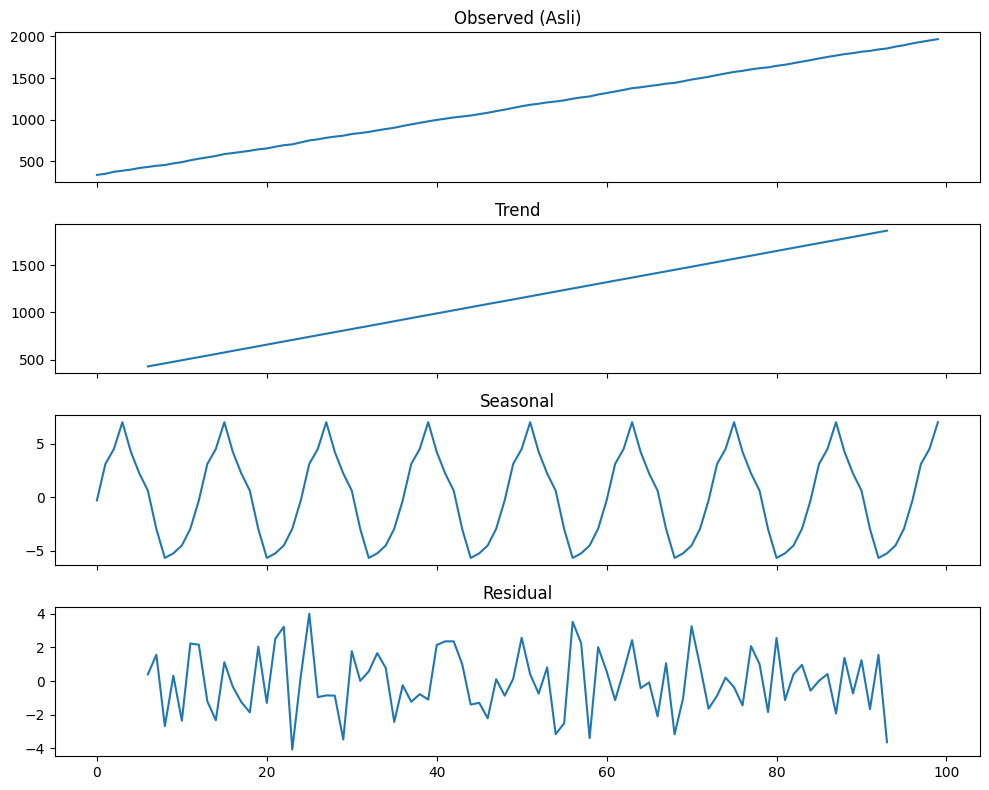

In [228]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [229]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1033)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*33, 10*33 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

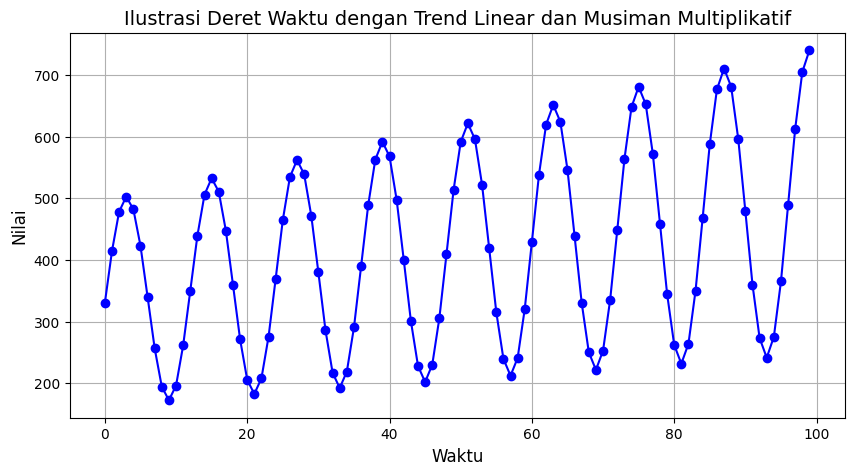

In [230]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [231]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

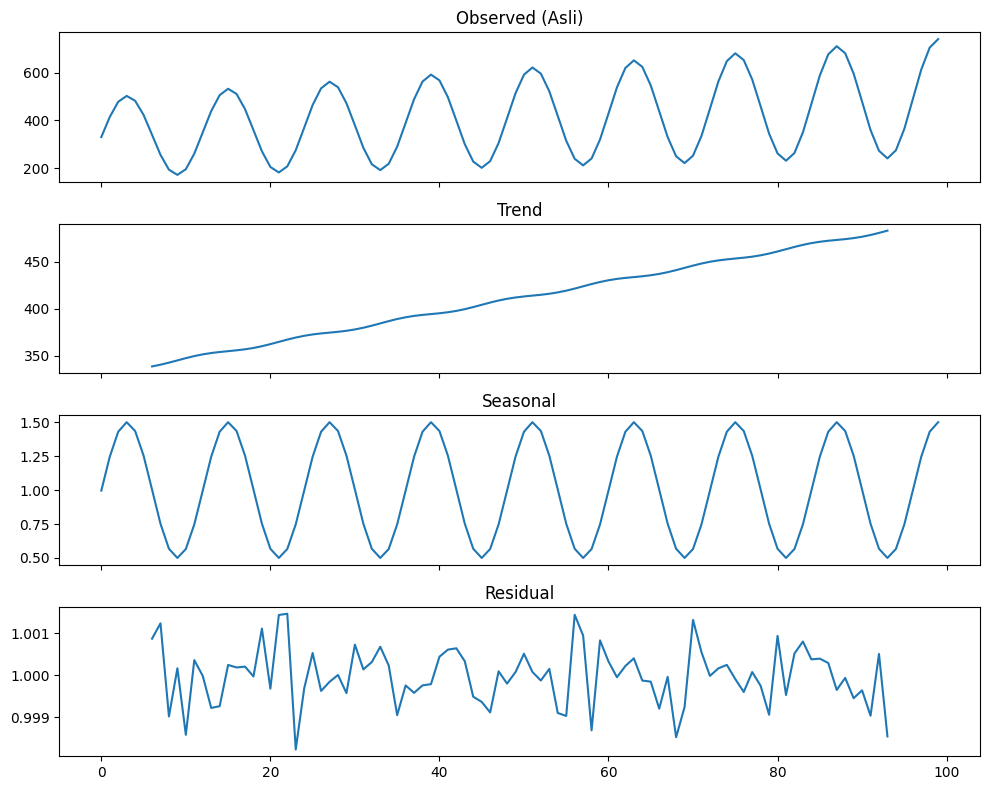

In [232]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

In [233]:
# Parameter
np.random.seed(1033)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

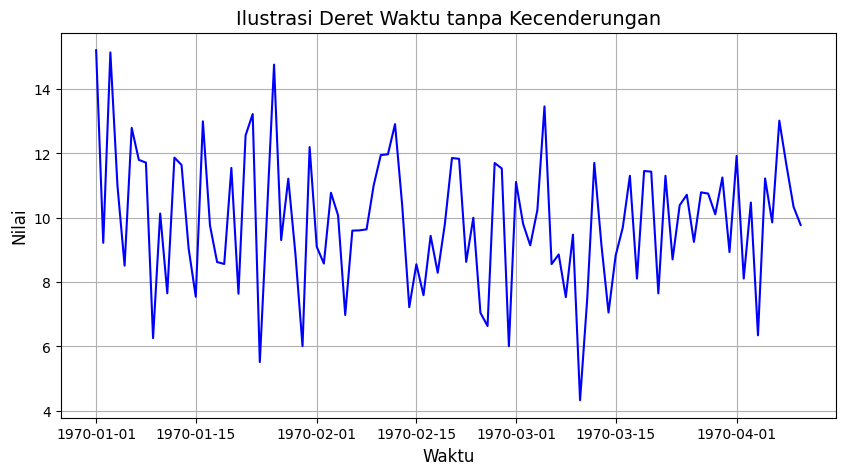

In [234]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

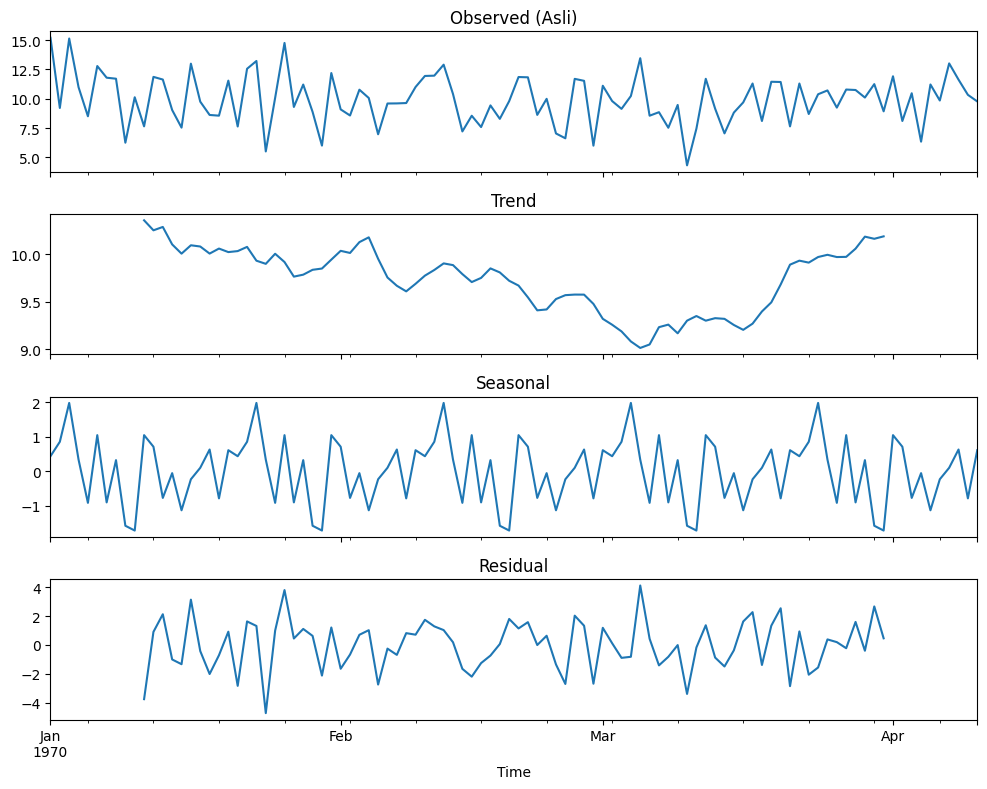

In [235]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?